# Shoelace Constraint Toggle — Comparison

Compares correction results using gradient-based Jacobian only vs. gradient + shoelace (geometric quad-cell area) enforcement.

**Key difference:** The gradient-based Jacobian determinant (`np.gradient` central differences) can report positive values even when the actual geometric quad cells are folded (negative shoelace area). Enabling `enforce_shoelace=True` adds an additional constraint to the SLSQP optimiser that requires all quad-cell areas to remain positive.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from modules.dvfopt import (
    iterative_parallel,
    iterative_with_jacobians2,
    jacobian_det2D,
    shoelace_det2D,
    generate_random_dvf,
)
from modules.dvfviz import (
    plot_deformations,
    plot_grid_before_after,
    plot_checkerboard_before_after,
    plot_neg_jdet_neighborhoods,
)
from modules.testcases import (
    SYNTHETIC_CASES, RANDOM_DVF_CASES,
    make_deformation, make_random_dvf,
)

## Helper: run both modes and compare

In [2]:
JDET_THRESHOLD = 0.01

def summarize(label, deformation, phi):
    """Print Jacobian and shoelace stats for a corrected field."""
    jac = jacobian_det2D(phi)
    shoe = shoelace_det2D(phi)
    phi_init = np.stack([deformation[-2, 0], deformation[-1, 0]])
    l2 = float(np.sqrt(np.sum((phi - phi_init) ** 2)))
    n_neg_jac = int((jac <= 0).sum())
    n_neg_shoe = int((shoe <= 0).sum())
    min_jac = float(jac.min())
    min_shoe = float(shoe.min())
    print(f"  [{label}]  neg_jdet={n_neg_jac}  min_jdet={min_jac:+.4f}"
          f"  neg_shoe={n_neg_shoe}  min_shoe={min_shoe:+.4f}  L2={l2:.4f}")
    return dict(n_neg_jac=n_neg_jac, n_neg_shoe=n_neg_shoe,
                min_jac=min_jac, min_shoe=min_shoe, l2=l2)


def compare(key, deformation, msample=None, fsample=None):
    """Run correction with and without shoelace enforcement, compare."""
    print(f"\n{'='*70}")
    print(f"  {key}  |  shape={deformation.shape[-2:]}")
    print(f"{'='*70}")

    # Initial stats
    jac0 = jacobian_det2D(np.stack([deformation[-2, 0], deformation[-1, 0]]))
    shoe0 = shoelace_det2D(np.stack([deformation[-2, 0], deformation[-1, 0]]))
    print(f"  [initial]  neg_jdet={int((jac0 <= 0).sum())}  min_jdet={float(jac0.min()):+.4f}"
          f"  neg_shoe={int((shoe0 <= 0).sum())}  min_shoe={float(shoe0.min()):+.4f}")

    # --- Standard (Jacobian only) ---
    t0 = time.perf_counter()
    phi_std = iterative_parallel(
        deformation.copy(), verbose=1, threshold=JDET_THRESHOLD,
        enforce_shoelace=False,
    )
    t_std = time.perf_counter() - t0
    stats_std = summarize("jdet-only", deformation, phi_std)
    print(f"  Time (jdet-only): {t_std:.2f}s")

    # --- With shoelace enforcement ---
    t0 = time.perf_counter()
    phi_shoe = iterative_parallel(
        deformation.copy(), verbose=1, threshold=JDET_THRESHOLD,
        enforce_shoelace=True,
    )
    t_shoe = time.perf_counter() - t0
    stats_shoe = summarize("jdet+shoe", deformation, phi_shoe)
    print(f"  Time (jdet+shoe): {t_shoe:.2f}s")

    # --- Visualisations ---
    plot_checkerboard_before_after(deformation, phi_std,
                                   title=f"{key} — Jdet only")
    plot_checkerboard_before_after(deformation, phi_shoe,
                                   title=f"{key} — Jdet + Shoelace")
    plot_neg_jdet_neighborhoods(deformation, phi_std,
                                title=f"{key} — Jdet only")
    plot_neg_jdet_neighborhoods(deformation, phi_shoe,
                                title=f"{key} — Jdet + Shoelace")
    plot_grid_before_after(deformation, phi_std,
                           title=f"{key} — Jdet only")
    plot_grid_before_after(deformation, phi_shoe,
                           title=f"{key} — Jdet + Shoelace")

    return stats_std, stats_shoe

## Synthetic test cases


  01a_10x10_crossing  |  shape=(10, 10)
  [initial]  neg_jdet=9  min_jdet=-1.0246  neg_shoe=10  min_shoe=-0.7716
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.024567
[iter    1]  serial  fix (  3,  5)  neg_pixels=9
         -> neg_jdet     0  min_jdet +0.010000  L2 2.2706  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      9 ->     0
  Min Jdet  -1.024567 -> +0.010000
  L2 error         : 2.270564
  Time             : 0.16s
  [jdet-only]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=4  min_shoe=-0.9718  L2=2.2706
  Time (jdet-only): 0.16s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 9  |  min Jdet: -1.024567
[iter    1]  serial  fix (  3,  5)  neg_p

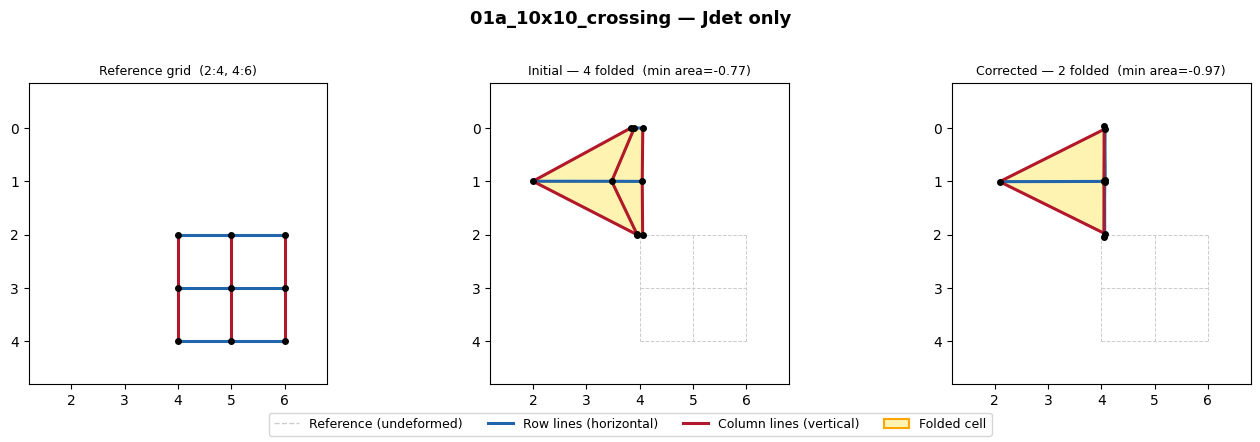

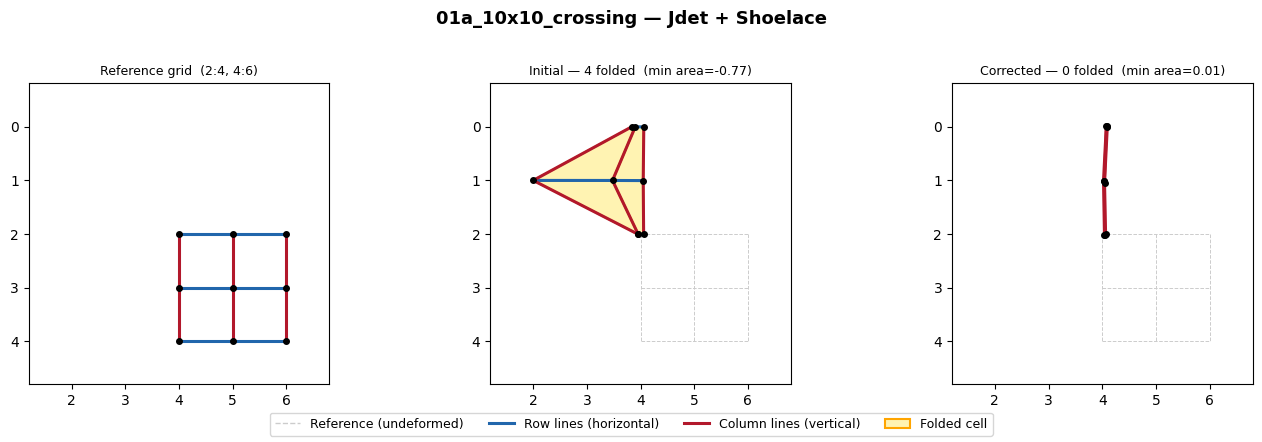

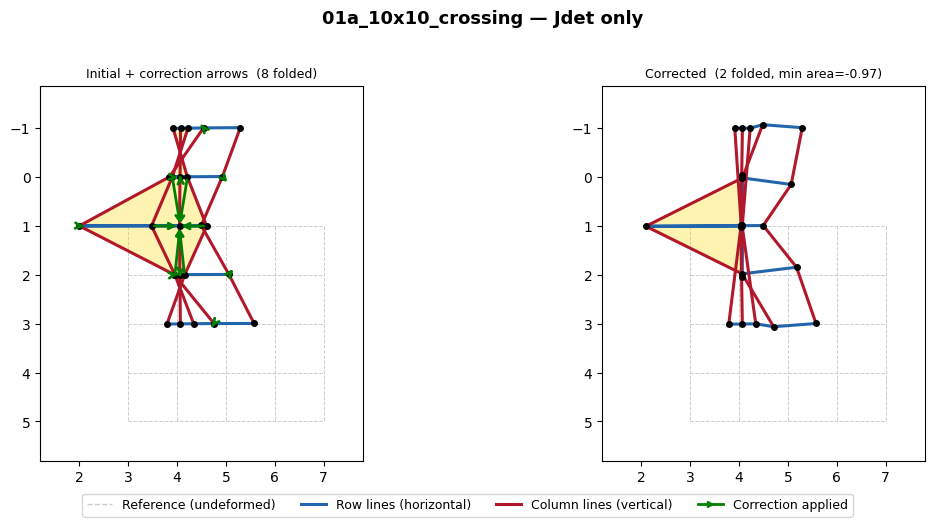

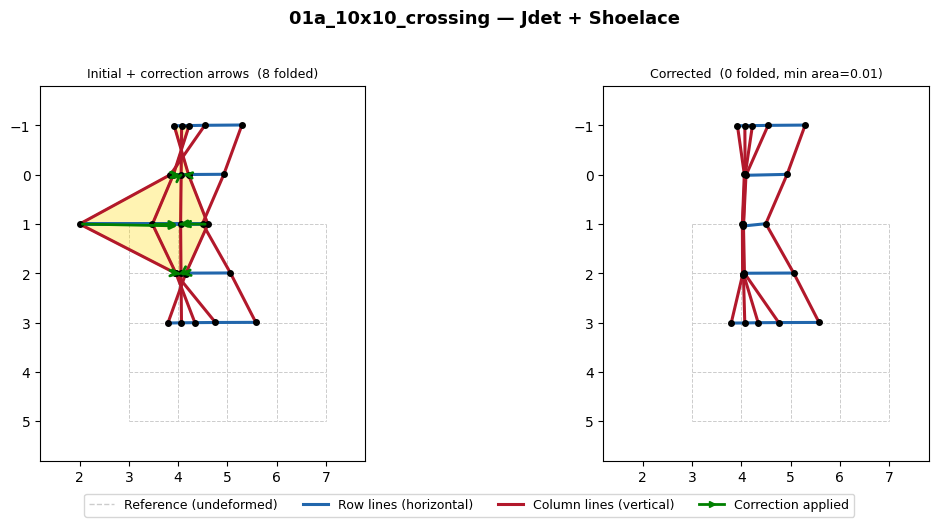

c:\Users\Andy\Documents\GitHub\UCI-iGravi\deformation-field-processing\modules\dvfviz.py:842: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.87, 1])


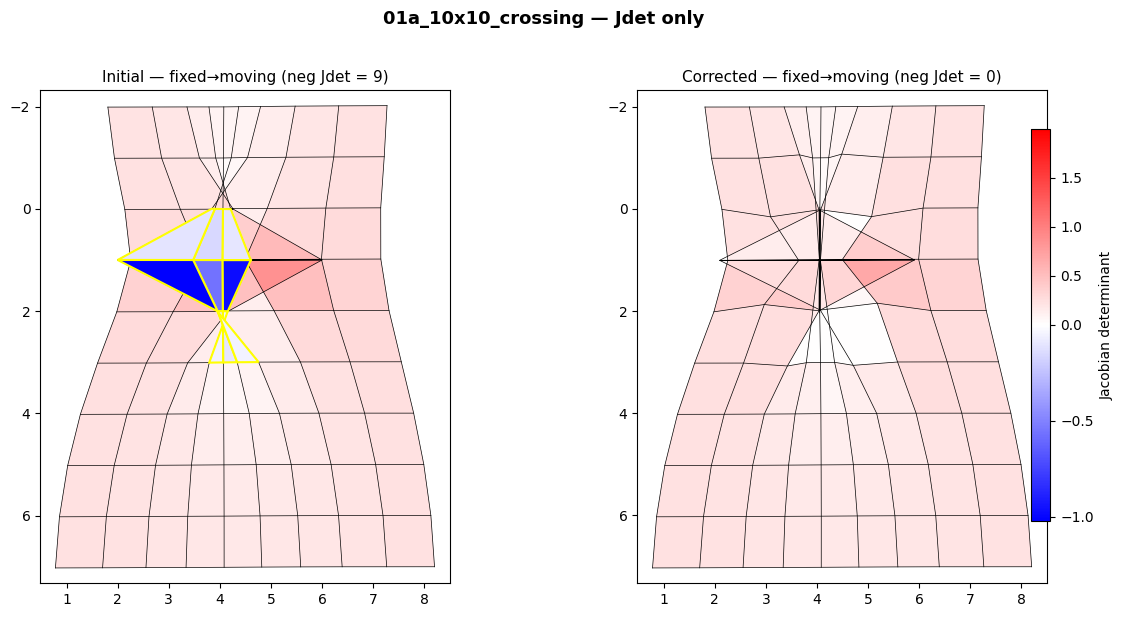

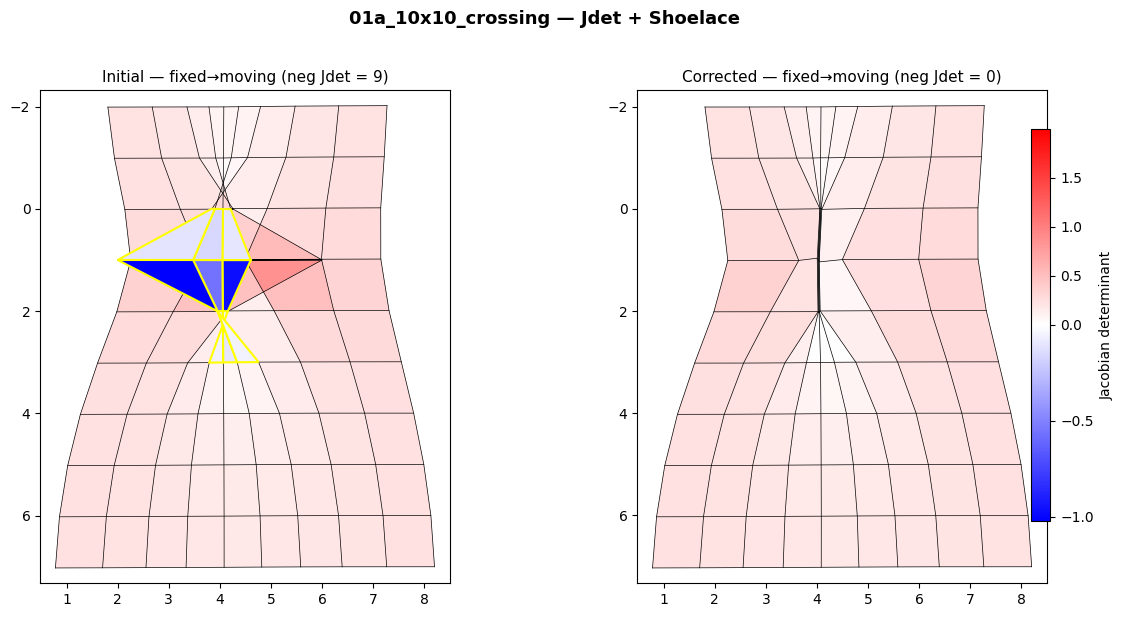


  01b_10x10_opposite  |  shape=(10, 10)
  [initial]  neg_jdet=6  min_jdet=-1.1540  neg_shoe=7  min_shoe=-0.5943
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 6  |  min Jdet: -1.154032
[iter    1]  serial  fix (  2,  1)  neg_pixels=4
         -> neg_jdet     0  min_jdet +0.010000  L2 1.4622  win 9  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP — hybrid parallel)
------------------------------------------------------------
  Grid size        : 10 x 10
  Iterations       : 1  (serial=1, parallel=0)
  Neg-Jdet      6 ->     0
  Min Jdet  -1.154032 -> +0.010000
  L2 error         : 1.462154
  Time             : 0.15s
  [jdet-only]  neg_jdet=0  min_jdet=+0.0100  neg_shoe=3  min_shoe=-0.0987  L2=1.4622
  Time (jdet-only): 0.15s
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 6  |  min Jdet: -1.154032
[iter    1]  serial  fix (  2,  1)  neg_pi

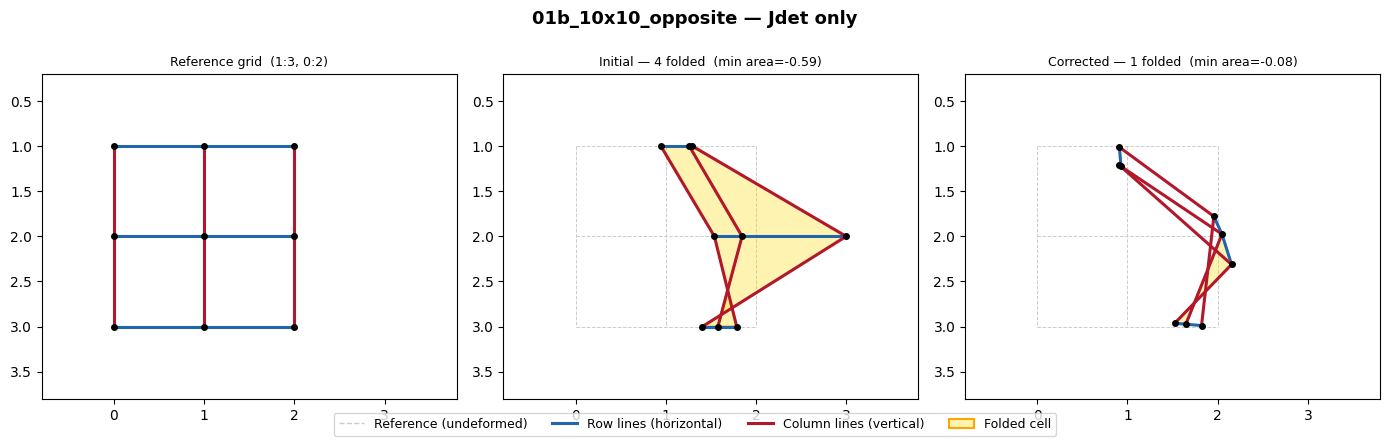

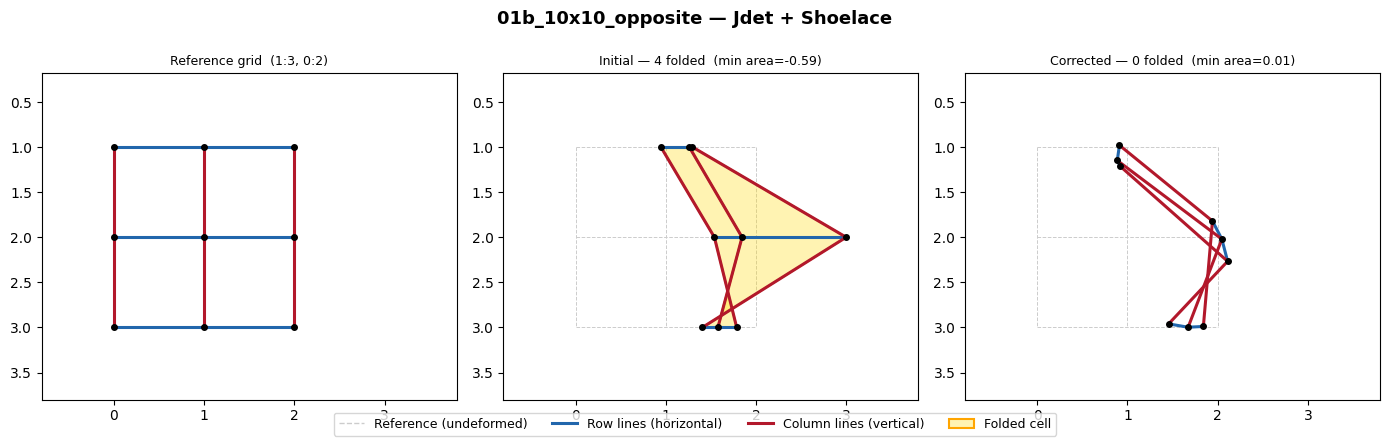

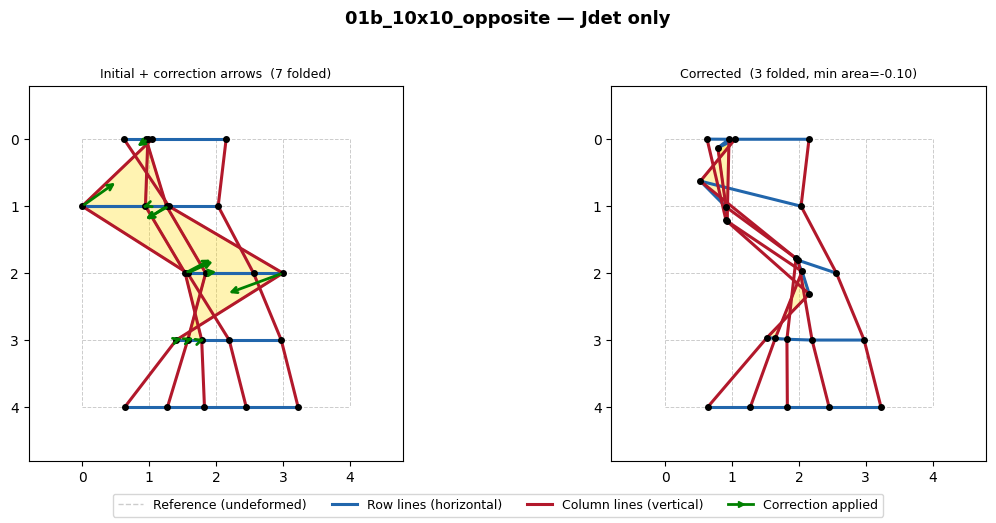

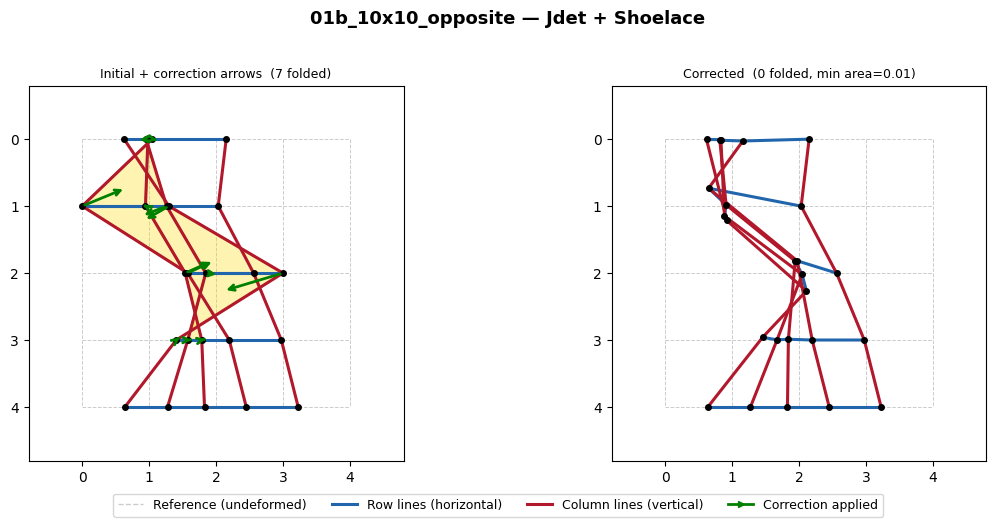

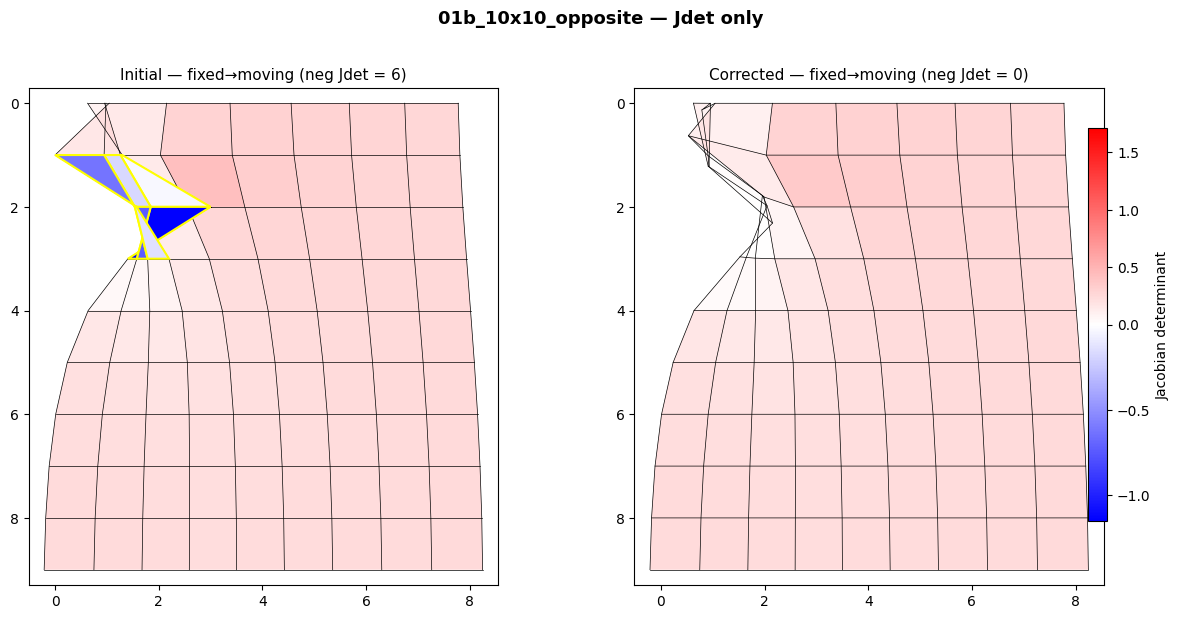

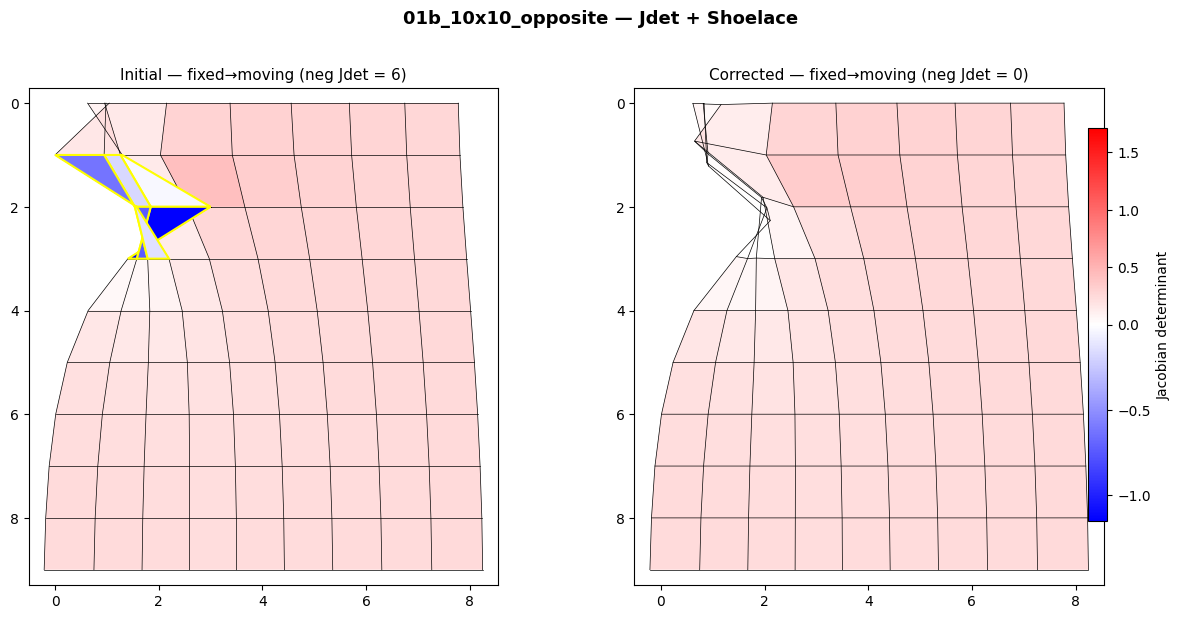

In [3]:
for case_key in ["01a_10x10_crossing", "01b_10x10_opposite"]:
    deformation, msample, fsample = make_deformation(case_key)
    s_std, s_shoe = compare(case_key, deformation,
                            msample=msample, fsample=fsample)

## Random DVF test cases

In [ ]:
for case_key in ["03a_10x10_random_seed_42", "01f_20x20_random_seed_42"]:
    deformation = make_random_dvf(case_key)
    s_std, s_shoe = compare(case_key, deformation)


  03a_10x10_random_seed_42  |  shape=(10, 10)
  [initial]  neg_jdet=43  min_jdet=-34.2105  neg_shoe=39  min_shoe=-28.0464
[init] Grid 10x10  |  threshold=0.01  |  method=SLSQP  |  workers=24  |  min_window=9
[init] Neg-Jdet pixels: 43  |  min Jdet: -34.210474
[iter    1]  serial  fix (  3,  1)  neg_pixels=24
         -> neg_jdet    17  min_jdet -52.373797  L2 18.4694  win 9  sub-iters 1
[iter    2]  serial  fix (  1,  8)  neg_pixels=6
         -> neg_jdet    18  min_jdet -20.538568  L2 17.9678  win 9  sub-iters 1
[iter    3]  serial  fix (  2,  1)  neg_pixels=9
         -> neg_jdet    16  min_jdet -41.928442  L2 18.6892  win 9  sub-iters 1
[iter    4]  serial  fix (  8,  1)  neg_pixels=6
         -> neg_jdet    14  min_jdet -41.928442  L2 17.4897  win 9  sub-iters 1
[iter    5]  serial  fix (  1,  2)  neg_pixels=5
         -> neg_jdet    15  min_jdet -41.919193  L2 18.8139  win 9  sub-iters 1
[iter    6]  serial  fix (  8,  1)  neg_pixels=6
         -> neg_jdet    14  min_jdet -41.919

## Summary comparison table
Quick view of all test cases side-by-side.

In [ ]:
results = {}
for case_key in list(SYNTHETIC_CASES.keys())[:4]:
    deformation, _, _ = make_deformation(case_key)
    jac0 = jacobian_det2D(np.stack([deformation[-2, 0], deformation[-1, 0]]))
    shoe0 = shoelace_det2D(np.stack([deformation[-2, 0], deformation[-1, 0]]))
    if int((jac0 <= 0).sum()) == 0:
        continue  # skip cases with no neg jdet

    phi_std = iterative_parallel(deformation.copy(), verbose=0,
                                  threshold=JDET_THRESHOLD, enforce_shoelace=False)
    phi_shoe = iterative_parallel(deformation.copy(), verbose=0,
                                   threshold=JDET_THRESHOLD, enforce_shoelace=True)
    results[case_key] = {
        "std": summarize("std", deformation, phi_std),
        "shoe": summarize("shoe", deformation, phi_shoe),
    }

print(f"\n{'Case':<25s} {'Mode':<12s} {'Neg Jdet':>8s} {'Min Jdet':>10s} "
      f"{'Neg Shoe':>8s} {'Min Shoe':>10s} {'L2':>8s}")
print("-" * 85)
for case_key, r in results.items():
    for mode, label in [("std", "jdet-only"), ("shoe", "jdet+shoe")]:
        s = r[mode]
        print(f"{case_key:<25s} {label:<12s} {s['n_neg_jac']:>8d} {s['min_jac']:>+10.4f} "
              f"{s['n_neg_shoe']:>8d} {s['min_shoe']:>+10.4f} {s['l2']:>8.4f}")